In [1]:
#DATASET UNDERSTANDING
import pandas as pd
df=pd.read_csv(r"E:INTERNSHIPS\DECODE LABS Intern\WEEK 3(DECODE LABS)\Mall_Customers.csv")
df.head(5)
df.tail(5)
df.shape
df.dtypes
df.isnull().sum()
df.duplicated().sum()
df.describe()
df['Gender'].value_counts()
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

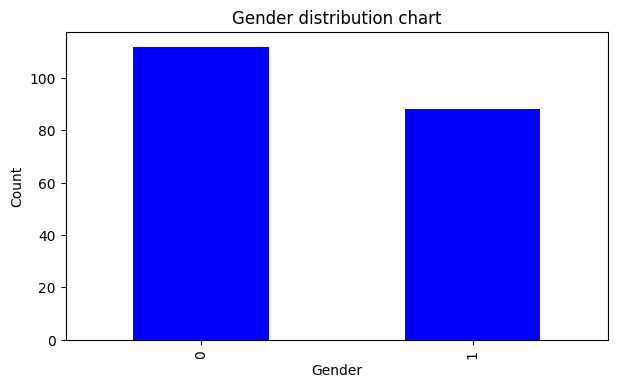

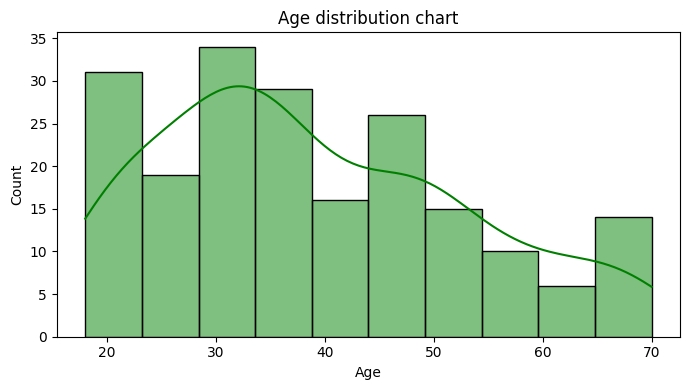

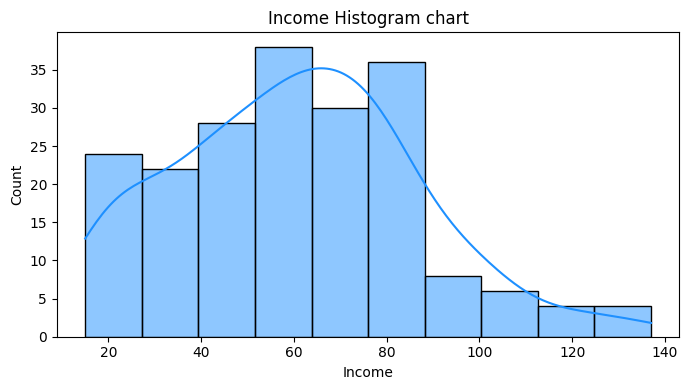

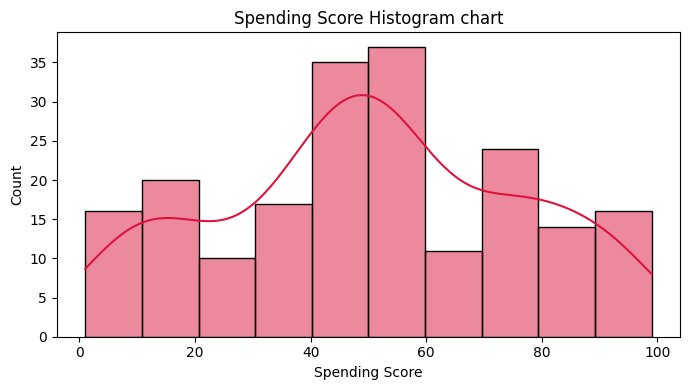

In [28]:
#BASIC VISUALIZATIONS
import matplotlib.pyplot as plt
import seaborn as sns

#Gender Distribution Chart
plt.figure(figsize=(7,4))
df['Gender'].value_counts().plot(kind='bar',color='blue')
plt.title('Gender distribution chart')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.savefig(r'E:INTERNSHIPS\DECODE LABS Intern\WEEK 3(DECODE LABS)\Charts\Gender distribution chart.png',dpi=300,bbox_inches='tight')
plt.show()

#Age distribution chart
plt.figure(figsize=(7,4))
sns.histplot(df['Age'],bins=10,kde=True,color='Green',edgecolor='Black')
plt.title('Age distribution chart')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(r'E:INTERNSHIPS\DECODE LABS Intern\WEEK 3(DECODE LABS)\Charts\Age distribution chart.png',dpi=300,bbox_inches='tight')
plt.show()

#Income Histogram
plt.figure(figsize=(7,4))
sns.histplot(df['Annual Income'],bins=10,kde=True,color='dodgerblue',edgecolor='Black')
plt.title('Income Histogram chart')
plt.xlabel('Income')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(r'E:INTERNSHIPS\DECODE LABS Intern\WEEK 3(DECODE LABS)\Charts\Income Histogram chart.png',dpi=300,bbox_inches='tight')
plt.show()

#Spending score histogram
plt.figure(figsize=(7,4))
sns.histplot(df['Spending Score'],bins=10,kde=True,color='crimson',edgecolor='Black')
plt.title('Spending Score Histogram chart')
plt.xlabel('Spending Score')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(r'E:INTERNSHIPS\DECODE LABS Intern\WEEK 3(DECODE LABS)\Charts\Spending Score Histogram chart.png',dpi=300,bbox_inches='tight')
plt.show()


(200, 5)


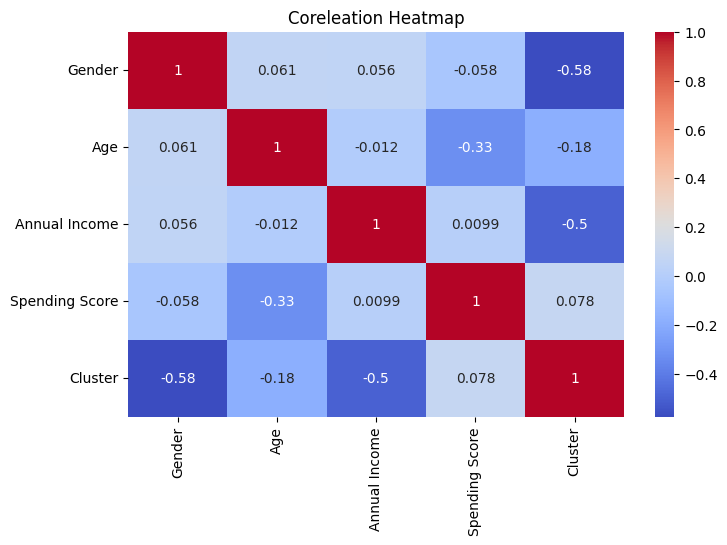

In [32]:
#Change Income and Spending score column names
df.rename(columns={'Annual Income (k$)':'Annual Income','Spending Score (1-100)':'Spending Score'},inplace=True)
df.columns

#Drop the Customer ID column
# df=df.drop("CustomerID" , axis=1)

#Label Encoding is now apply to Gender
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])
df.head()

#Selecting features
x=df
x.head()

#Now applying standard scalar
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
#---------------------
x_scaled_df=pd.DataFrame(
    x_scaled,
    columns=x.columns
)
x_scaled_df.head()

print(x_scaled.shape)

#Coreleation heatmap
plt.figure(figsize=(8,5))
sns.heatmap(x_scaled_df.corr(),annot=True,cmap='coolwarm')
plt.title('Coreleation Heatmap')
plt.savefig(r'E:INTERNSHIPS\DECODE LABS Intern\WEEK 3(DECODE LABS)\Charts\Coreleation Heatmap.png',dpi=300,bbox_inches='tight')
plt.show()

Shape before applying PCA
(200, 5)
Shape after applying PCA
(200, 2)
Variance ratio of each component
[0.36905662 0.25885365]
Overall Variance ratio
0.6279102648856218
        PC1       PC2
0  1.234166 -0.011519
1  1.507027  0.987284
2  1.375074 -0.949729
3  2.469519  0.615323
4  1.411813 -0.562934


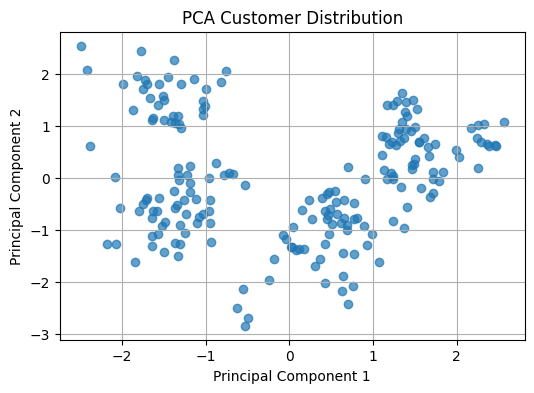

In [33]:
#Importing PCA(Principal component Analysis)
from sklearn.decomposition import PCA
pca=PCA(n_components=2)

#transforming data into 2 components
x_pca=pca.fit_transform(x_scaled)
print("Shape before applying PCA")
print(x_scaled.shape) #(200, 4)
print("Shape after applying PCA")
print(x_pca.shape) #(200, 2)

#now checking the variance ratio to each component
print("Variance ratio of each component")
print(pca.explained_variance_ratio_)
print("Overall Variance ratio")
print(pca.explained_variance_ratio_.sum())

# now convert pca dataframe
pca_df=pd.DataFrame(x_pca,columns=['PC1','PC2'])
print(pca_df.head())

#Making scatter plot,
plt.figure(figsize=(6,4))
plt.scatter(pca_df['PC1'],pca_df['PC2'],alpha=0.7)
plt.title("PCA Customer Distribution")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.savefig(r'E:INTERNSHIPS\DECODE LABS Intern\WEEK 3(DECODE LABS)\Charts\PCA Customer Distribution.png',dpi=300,bbox_inches='tight')
plt.show()

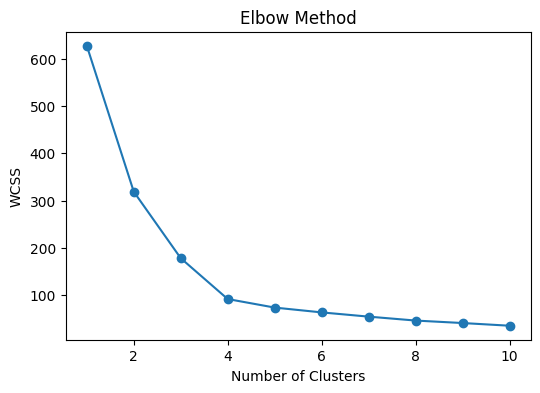

K=2,Silhouette=0.4772
K=3,Silhouette=0.4890
K=4,Silhouette=0.5704
K=5,Silhouette=0.5098
K=6,Silhouette=0.4752
K=7,Silhouette=0.4268
K=8,Silhouette=0.4543
K=9,Silhouette=0.4199
K=10,Silhouette=0.4293


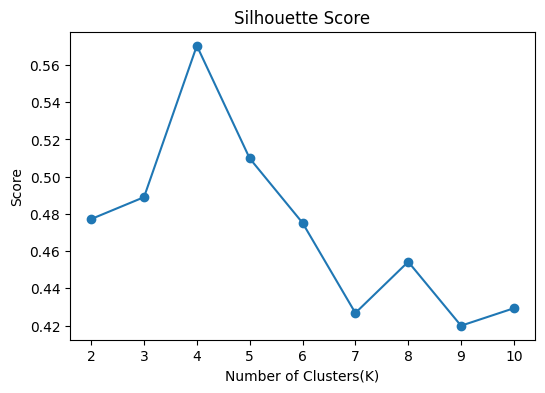

In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#Elbow Method
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,random_state=42,n_init=10)
    kmeans.fit(pca_df)
    wcss.append(kmeans.inertia_)

#Now plot Elbow Curve
plt.figure(figsize=(6,4))
plt.plot(range(1,11),wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid=True
plt.savefig(r'E:INTERNSHIPS\DECODE LABS Intern\WEEK 3(DECODE LABS)\Charts\Elbow Method.png',dpi=300,bbox_inches='tight')
plt.show()

#Silhouette Scores
sil_scores=[]

for i in range(2,11):
    kmeans=KMeans(n_clusters=i,random_state=42,n_init=10)
    labels=kmeans.fit_predict(pca_df)

    score=silhouette_score(
    pca_df,
    labels
    )
    sil_scores.append(score)
    print(f"K={i},Silhouette={score:.4f}"
         )
#Now plot Silhouette scores
plt.figure(figsize=(6,4))
plt.plot(range(2,11),sil_scores,marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters(K)")
plt.ylabel("Score")
plt.grid=True
plt.savefig(r'E:INTERNSHIPS\DECODE LABS Intern\WEEK 3(DECODE LABS)\Charts\Silhouette Score.png',dpi=300,bbox_inches='tight')
plt.show()

Cluster
1    61
2    54
0    50
3    35
Name: count, dtype: int64


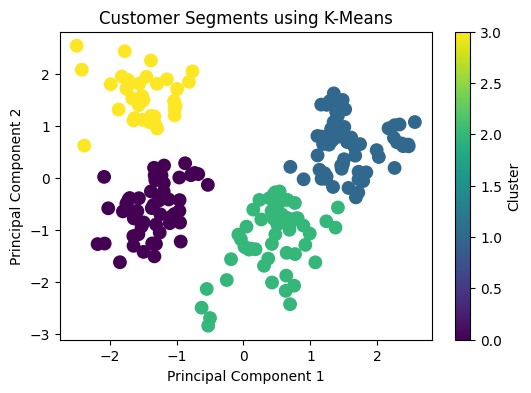

           Gender        Age  Annual Income  Spending Score
Cluster                                                    
0        0.820000  47.960000      73.380000       31.120000
1        0.180328  27.295082      49.819672       67.508197
2        0.129630  49.222222      46.222222       34.000000
3        0.828571  29.971429      83.085714       72.285714
--Gender Distribution acoording to clusters
Gender    0   1
Cluster        
0         9  41
1        50  11
2        47   7
3         6  29


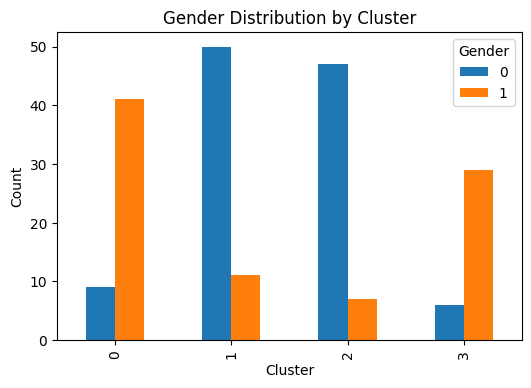

In [35]:
#Applying final value of K-Means that is 4
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=4,random_state=42,n_init=10)
clusters=kmeans.fit_predict(pca_df)
clusters[:10]

#Now Adding and verifying cluster column in dataset
df['Cluster']=clusters
df.head()
print(df['Cluster'].value_counts())

#PCA Visualization according to clusters
plt.figure(figsize=(6,4))
plt.scatter(pca_df['PC1'],pca_df['PC2'],c=df['Cluster'],cmap='viridis',s=80)
plt.title("Customer Segments using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.savefig(r'E:INTERNSHIPS\DECODE LABS Intern\WEEK 3(DECODE LABS)\Charts\Customer Segments using K-Means.png',dpi=300,bbox_inches='tight')
plt.show()

cluster_summary=df.groupby("Cluster").mean()
print(cluster_summary)

#Gender Distribution acoording to clusters
print("--Gender Distribution acoording to clusters")
gender_cluster=pd.crosstab(df['Cluster'],df['Gender'])
print(gender_cluster)

#Visualization of gender distribution
gender_cluster.plot(kind='bar',figsize=(6,4))
plt.title("Gender Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.savefig(r'E:INTERNSHIPS\DECODE LABS Intern\WEEK 3(DECODE LABS)\Charts\Gender Distribution by Cluster.png',dpi=300,bbox_inches='tight')
plt.show()


# Customer Persona Summary

| Cluster | Average Age | Average Income | Average Spending Score | Persona Name | Business Recommendation |
|----------|------------|--------------------|------------------------|--------------|------------------------|
| 0 | 29.91 | 81.50 | 73.88 | High-Value Customers | Offer premium products, exclusive discounts, and loyalty rewards. |
| 1 | 47.65 | 74.63 | 30.86 | Conservative Customers | Focus on value-based products and long-term retention strategies. |
| 2 | 49.22 | 46.22 | 34.00 | Budget-Conscious Customers | Provide discounts, coupons, and affordable product bundles. |
| 3 | 27.30 | 49.82 | 67.51 | Young Spenders | Promote trendy products, social media campaigns, and personalized offers. |

## Key Insights

- **Cluster 0** contains high-income customers with high spending behavior, making them the most valuable customer segment.
- **Cluster 1** consists of mature customers with good income but relatively low spending habits.
- **Cluster 2** represents budget-conscious customers who spend less and are price-sensitive.
- **Cluster 3** includes younger customers with moderate income and high spending tendencies.
- Different marketing strategies can be designed for each customer segment to improve customer engagement and business growth.